# Tópicos em Otimização Irrestrita

### Pacotes importados

In [6]:
using LinearAlgebra
using Printf
using Plots


### Machine epsilon

![image.png](attachment:17b541ce-5cec-4170-9d1b-c0c6f53fad7f.png)

In [15]:
# Machine epsilon calculation for Float64
E = 1.0

while 1.0 + E/2.0 > 1.0
    E = E/2.0
end

println("Calculated machine epsilon = ", E)
println("Julia eps(Float64)          = ", eps(Float64))


Calculated machine epsilon = 2.220446049250313e-16
Julia eps(Float64)          = 2.220446049250313e-16


### Newton's method: one variable

![image.png](attachment:04fc9bb4-afe7-4e7e-bfdb-3e3530658904.png)

Take the equation: $F(x) = x^2 - 2 = 0$. Apply the Newton's method with $x_0 = 2, \epsilon = 10^{-15}$. Present the results such as the following:

![image.png](attachment:132f352b-d118-4786-b8ea-51d48250a134.png)

Also plot the graph with the iterations $\times$ the value of F(x).

Newton's Method for F(x) = x² - 2
    k                      x                   F(x)                 |F(x)|
    0  2.000000000000000e+00  2.000000000000000e+00  2.000000000000000e+00
    1  1.500000000000000e+00  2.500000000000000e-01  2.500000000000000e-01
    2  1.416666666666667e+00  6.944444444444642e-03  6.944444444444642e-03
    3  1.414215686274510e+00  6.007304882871267e-06  6.007304882871267e-06
    4  1.414213562374690e+00  4.510614104447086e-12  4.510614104447086e-12
    5  1.414213562373095e+00  4.440892098500626e-16  4.440892098500626e-16

Approximate root = 1.4142135623730951
sqrt(2)          = 1.4142135623730951
F(root)          = 4.440892098500626e-16


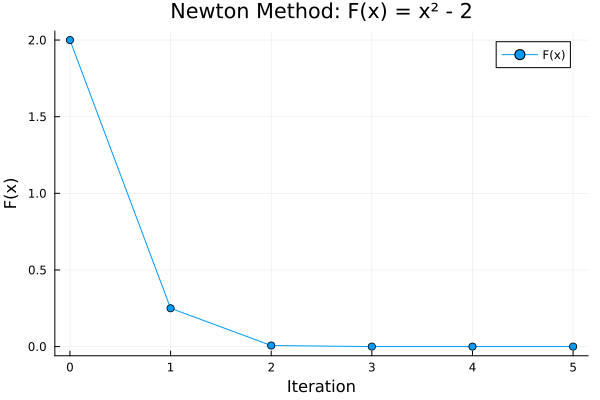

In [8]:
function newton_1d(F, dF, x0; tol=1e-15, maxiter=100)
    x = Float64(x0)
    history = []

    for k in 0:maxiter
        Fx = F(x)
        push!(history, (k, x, Fx, abs(Fx)))

        if abs(Fx) < tol
            break
        end

        dFx = dF(x)

        if abs(dFx) < eps(Float64)
            println("Derivative is too close to zero. Stopping.")
            break
        end

        x = x - Fx/dFx
    end

    return x, history
end

function print_newton_1d(history)
    @printf("%5s %22s %22s %22s\n", "k", "x", "F(x)", "|F(x)|")
    for (k, x, Fx, absFx) in history
        @printf("%5d %22.15e %22.15e %22.15e\n", k, x, Fx, absFx)
    end
end

# Example 1: F(x) = x² - 2
F(x) = x^2 - 2
dF(x) = 2x

x0 = 2.0
tol = 1e-15

root, history = newton_1d(F, dF, x0; tol=tol)

println("Newton's Method for F(x) = x² - 2")
print_newton_1d(history)
println("\nApproximate root = ", root)
println("sqrt(2)          = ", sqrt(2.0))
println("F(root)          = ", F(root))

iterations = [h[1] for h in history]
values_F = [h[3] for h in history]

plot(iterations, values_F,
     marker=:circle,
     xlabel="Iteration",
     ylabel="F(x)",
     title="Newton Method: F(x) = x² - 2",
     label="F(x)")


Another example: $F(x)=x-\sin(x)$. Run the example with $x_0=1$ and $\varepsilon=10^{-15}$.

Newton's Method for F(x) = x - sin(x)
    k                      x                   F(x)                 |F(x)|
    0  1.000000000000000e+00  1.585290151921035e-01  1.585290151921035e-01
    1  6.551450720424304e-01  4.587078604089578e-02  4.587078604089578e-02
    2  4.335903683634927e-01  1.345873795940100e-02  1.345873795940100e-02
    3  2.881484008925012e-01  3.970948460417290e-03  3.970948460417290e-03
    4  1.918323121506386e-01  1.174396923293297e-03  1.174396923293297e-03
    5  1.278096675607083e-01  3.476843492049853e-04  3.476843492049853e-04
    6  8.518323360286406e-02  1.029801567549449e-04  1.029801567549449e-04
    7  5.678195278661637e-02  3.050771704538047e-05  3.050771704538047e-05
    8  3.785260078111326e-02  9.038675803818563e-06  9.038675803818563e-06
    9  2.523446453501505e-02  2.678040884988853e-06  2.678040884988853e-06
   10  1.682279781087122e-02  7.934823667461732e-07  7.934823667461732e-07
   11  1.121514564046264e-02  2.351044078308107e-07  2.3510440

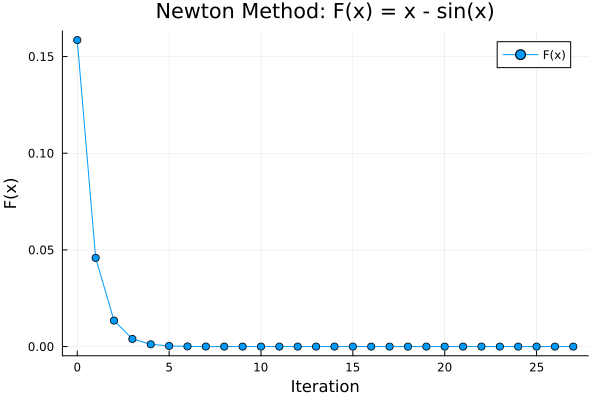

In [9]:
# Example 2: F(x) = x - sin(x)
F(x) = x - sin(x)
dF(x) = 1 - cos(x)

x0 = 1.0
tol = 1e-15

root, history = newton_1d(F, dF, x0; tol=tol, maxiter=200)

println("Newton's Method for F(x) = x - sin(x)")
print_newton_1d(history)
println("\nApproximate root = ", root)
println("F(root)          = ", F(root))
println("Iterations       = ", length(history)-1)

iterations = [h[1] for h in history]
values_F = [h[3] for h in history]

plot(iterations, values_F,
     marker=:circle,
     xlabel="Iteration",
     ylabel="F(x)",
     title="Newton Method: F(x) = x - sin(x)",
     label="F(x)")


Another example: $F(x)=\arctan(x)$. Run the example with $x_0=1.5$ and $\varepsilon=10^{-15}$. We set `maxiter` to 10, as the algorithm is not converging.

Derivative is too close to zero. Stopping.
Newton's Method for F(x) = arctan(x)
    k                      x                   F(x)                 |F(x)|
    0  1.500000000000000e+00  9.827937232473291e-01  9.827937232473291e-01
    1 -1.694079600553819e+00 -1.037546359137891e+00  1.037546359137891e+00
    2  2.321126961438388e+00  1.164002042421975e+00  1.164002042421975e+00
    3 -5.114087836777514e+00 -1.377694528702752e+00  1.377694528702752e+00
    4  3.229568391421002e+01  1.539842326908012e+00  1.539842326908012e+00
    5 -1.575316950821204e+03 -1.570161533990085e+00  1.570161533990085e+00
    6  3.894976007760884e+06  1.570796070053906e+00  1.570796070053906e+00
    7 -2.383028897355212e+13 -1.570796326794855e+00  1.570796326794855e+00

Last iterate = -2.3830288973552125e13
F(last)      = -1.5707963267948546
Iterations   = 7


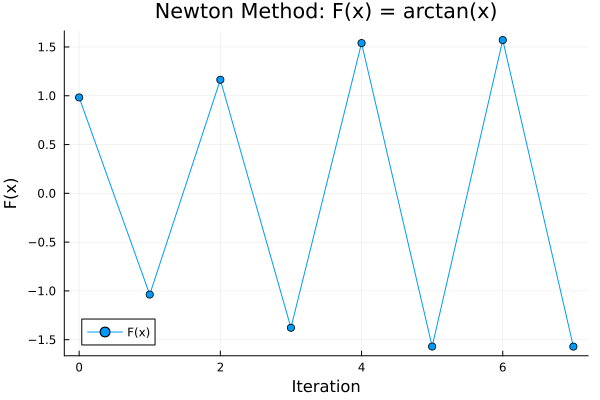

In [10]:
# Example 3: F(x) = arctan(x)
F(x) = atan(x)
dF(x) = 1/(1+x^2)

x0 = 1.5
tol = 1e-15

root, history = newton_1d(F, dF, x0; tol=tol, maxiter=10)

println("Newton's Method for F(x) = arctan(x)")
print_newton_1d(history)
println("\nLast iterate = ", root)
println("F(last)      = ", F(root))
println("Iterations   = ", length(history)-1)

iterations = [h[1] for h in history]
values_F = [h[3] for h in history]

plot(iterations, values_F,
     marker=:circle,
     xlabel="Iteration",
     ylabel="F(x)",
     title="Newton Method: F(x) = arctan(x)",
     label="F(x)")


### Algorithm 7.3: Newton's method: $n$ variables

![image.png](attachment:cfd21de5-3e10-425e-a245-4256e0587942.png)

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Newton's Method for the first system
    k                              x                           F(x)           ||F(x)||
    0                     [1.0, 1.0]          [3.0, 1.718281828459]     3.45723769e+00
    1 [0.152359213639, 1.195281572722] [0.756629795348, 0.872274931698]     1.15470871e+00
    2 [-0.010837680936, 1.036111167259] [0.051968444374, 0.101513475678]     1.14042558e-01
    3 [-0.000889664601, 1.001535316494] [0.001294452485, 0.003723755724]     3.94232976e-03
    4 [-1.370089e-6, 1.000002938708]     [3.137249e-6, 7.446062e-6]     8.07998556e-06
    5     [-6.0e-12, 1.000000000011]             [1.1e-11, 2.7e-11]     2.88311226e-11
    6                    [-0.0, 1.0]                     [0.0, 0.0]     4.44089210e-16

Approximate solution = [-1.0463793574265223e-16, 1.0000000000000002]
F(solution)          = [0.0, 4.440892098500626e-16]


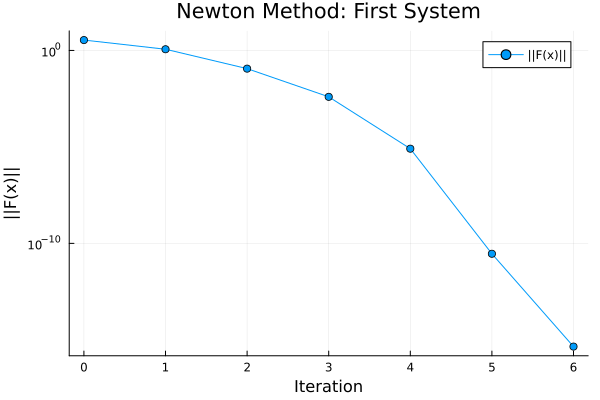

In [16]:
function newton_nd(F, J, x0; tol=1e-15, maxiter=100)
    x = Float64.(copy(x0))
    history = []

    for k in 0:maxiter
        Fx = F(x)
        normFx = norm(Fx)
        push!(history, (k, copy(x), copy(Fx), normFx))

        if normFx < tol
            break
        end

        dx = -J(x) \ Fx
        x = x + dx
    end

    return x, history
end

function print_newton_nd(history)
    @printf("%5s %30s %30s %18s\n", "k", "x", "F(x)", "||F(x)||")
    for (k, x, Fx, normFx) in history
        @printf("%5d %30s %30s %18.8e\n", k, string(round.(x, digits=12)), string(round.(Fx, digits=12)), normFx)
    end
end

# Example:
# F(x) = [(x1+1)^2 + x2^2 - 2;
#         exp(x1) + x2^3 - 2]
function F1(x)
    x1, x2 = x
    return [
        (x1 + 1)^2 + x2^2 - 2,
        exp(x1) + x2^3 - 2
    ]
end

function J1(x)
    x1, x2 = x
    return [
        2*(x1 + 1)   2*x2;
        exp(x1)      3*x2^2
    ]
end

x0 = [1.0, 1.0]
tol = 1e-15

root, history = newton_nd(F1, J1, x0; tol=tol)

println("Newton's Method for the first system")
print_newton_nd(history)
println("\nApproximate solution = ", root)
println("F(solution)          = ", F1(root))

iterations = [h[1] for h in history]
norms = [h[4] for h in history]

plot(iterations, norms,
     yscale=:log10,
     marker=:circle,
     xlabel="Iteration",
     ylabel="||F(x)||",
     title="Newton Method: First System",
     label="||F(x)||")


Example: $F(x)=\left(\begin{array}{c}x_1^3 - 3 x_1 x_2^2 -1 \\ x_2^3 - 3x_1^2 x_2\end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Newton's Method for the second system with x0 = [1, 1]
    k                              x                           F(x)           ||F(x)||
    0                     [1.0, 1.0]                   [-3.0, -2.0]     3.60555128e+00
    1          [0.666666666667, 0.5] [-1.203703703704, -0.541666666667]     1.31996416e+00
    2 [0.578844444444, -0.127466666667] [-0.834266626169, 0.126056237992]     8.43736321e-01
    3 [1.246963981575, 0.313578425155] [0.571080951306, -1.431932700419]     1.54161108e+00
    4 [1.008948197752, 0.113677965155] [-0.012029422899, -0.345695455665]     3.45904691e-01
    5 [0.987868045978, 0.003836843643] [-0.035999723083, -0.011232878151]     3.77115051e-02
    6 [1.00013414421, -9.5322185e-5] [0.000402459354, 0.000286043281]     4.93755294e-04
    7    [1.00000000891, -2.5568e-8]          [2.673e-8, 7.6704e-8]     8.12284357e-08
    8                    [1.0, -0.0]                    [-0.0, 0.0]     2.15445629e-15
    9                     [1.0, 0.0]          

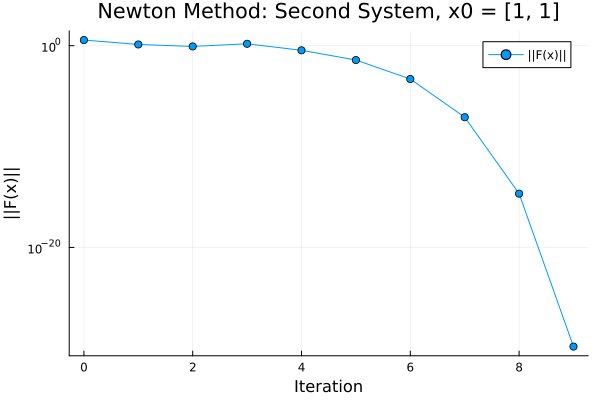

In [12]:
# System:
# F(x) = [x1^3 - 3*x1*x2^2 - 1;
#         x2^3 - 3*x1^2*x2]
function F2(x)
    x1, x2 = x
    return [
        x1^3 - 3*x1*x2^2 - 1,
        x2^3 - 3*x1^2*x2
    ]
end

function J2(x)
    x1, x2 = x
    return [
        3*x1^2 - 3*x2^2    -6*x1*x2;
        -6*x1*x2            3*x2^2 - 3*x1^2
    ]
end

x0 = [1.0, 1.0]
tol = 1e-15

root, history = newton_nd(F2, J2, x0; tol=tol)

println("Newton's Method for the second system with x0 = [1, 1]")
print_newton_nd(history)
println("\nApproximate solution = ", root)
println("F(solution)          = ", F2(root))

iterations = [h[1] for h in history]
norms = [h[4] for h in history]

plot(iterations, norms,
     yscale=:log10,
     marker=:circle,
     xlabel="Iteration",
     ylabel="||F(x)||",
     title="Newton Method: Second System, x0 = [1, 1]",
     label="||F(x)||")


Run the example with $x_0= \left(\begin{array}{c} -1 \\ -1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Newton's Method for the second system with x0 = [-1, -1]
    k                              x                           F(x)           ||F(x)||
    0                   [-1.0, -1.0]                     [1.0, 2.0]     2.23606798e+00
    1 [-0.666666666667, -0.833333333333] [0.092592592593, 0.532407407407]     5.40398960e-01
    2 [-0.508691916187, -0.841099874413] [-0.052012157601, 0.057912584449]     7.78404264e-02
    3 [-0.499329995644, -0.866269171788] [-0.000373111391, -0.002105852141]     2.13865036e-03
    4 [-0.49999991137, -0.866024903157]     [-1.433613e-6, 5.20673e-7]     1.52523667e-06
    5        [-0.5, -0.866025403785]                [1.0e-12, -0.0]     7.75299009e-13
    6        [-0.5, -0.866025403784]                   [-0.0, -0.0]     2.48253415e-16

Approximate solution = [-0.49999999999999994, -0.8660254037844386]
F(solution)          = [-2.220446049250313e-16, -1.1102230246251565e-16]


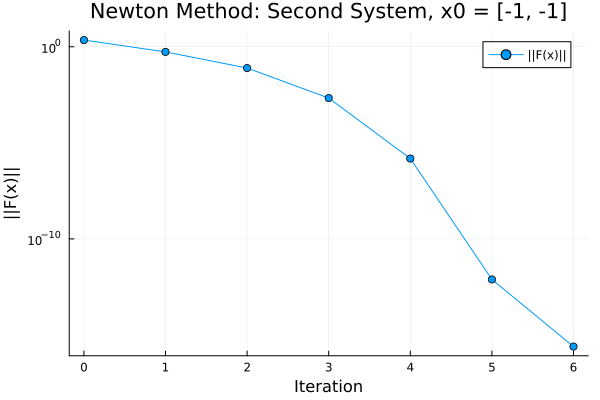

In [13]:
x0 = [-1.0, -1.0]
tol = 1e-15

root, history = newton_nd(F2, J2, x0; tol=tol)

println("Newton's Method for the second system with x0 = [-1, -1]")
print_newton_nd(history)
println("\nApproximate solution = ", root)
println("F(solution)          = ", F2(root))

iterations = [h[1] for h in history]
norms = [h[4] for h in history]

plot(iterations, norms,
     yscale=:log10,
     marker=:circle,
     xlabel="Iteration",
     ylabel="||F(x)||",
     title="Newton Method: Second System, x0 = [-1, -1]",
     label="||F(x)||")


Run the example with $x_0= \left(\begin{array}{c} 0 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Newton's Method for the second system with x0 = [0, 1]
    k                              x                           F(x)           ||F(x)||
    0                     [0.0, 1.0]                    [-1.0, 1.0]     1.41421356e+00
    1 [-0.333333333333, 0.666666666667] [-0.592592592593, 0.074074074074]     5.97204278e-01
    2 [-0.582222222222, 0.924444444444] [0.295333750343, -0.1500841262]     3.31281254e-01
    3 [-0.508790803289, 0.868165511887] [0.018734519711, -0.019874816267]     2.73128276e-02
    4 [-0.500068739067, 0.865982218693] [-9.109274e-6, -0.000243365498]     2.43535921e-04
    5 [-0.499999996289, 0.866025398339]         [-1.9715e-8, 1.473e-9]     1.97701144e-08
    6         [-0.5, 0.866025403784]                    [0.0, -0.0]     4.96506831e-16

Approximate solution = [-0.5000000000000001, 0.8660254037844387]
F(solution)          = [4.440892098500626e-16, -2.220446049250313e-16]


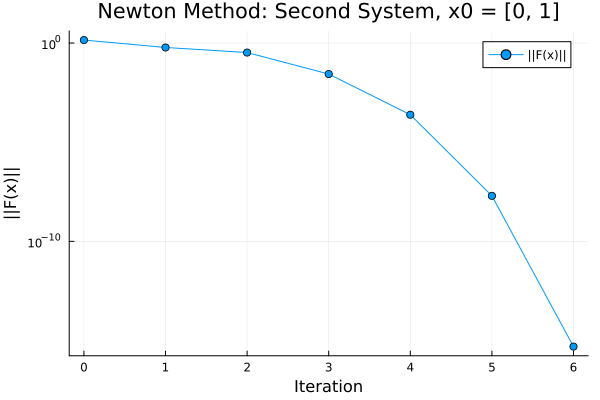

In [14]:
x0 = [0.0, 1.0]
tol = 1e-15

root, history = newton_nd(F2, J2, x0; tol=tol)

println("Newton's Method for the second system with x0 = [0, 1]")
print_newton_nd(history)
println("\nApproximate solution = ", root)
println("F(solution)          = ", F2(root))

iterations = [h[1] for h in history]
norms = [h[4] for h in history]

plot(iterations, norms,
     yscale=:log10,
     marker=:circle,
     xlabel="Iteration",
     ylabel="||F(x)||",
     title="Newton Method: Second System, x0 = [0, 1]",
     label="||F(x)||")
